# Jour 4 — Évaluation rigoureuse et mise en production

Dataset : **Breast Cancer** (sklearn). Champion déployé en API + Streamlit.

## Phase 0 — Mise en route

In [41]:
%pip install --user scikit-learn joblib flask streamlit matplotlib tensorflow

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone, BaseEstimator, ClassifierMixin


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

print(f"Breast Cancer : {X.shape[0]} patients, {X.shape[1]} mesures")
print(f"Classes : 0 = maligne ({(y == 0).sum()}), 1 = bénigne ({(y == 1).sum()})")
print(f"Exemples de features : {feature_names[:5]}")

Breast Cancer : 569 patients, 30 mesures
Classes : 0 = maligne (212), 1 = bénigne (357)
Exemples de features : [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


## Phase 1 — Séparer les données proprement, train / validation / test

In [ ]:
def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):

    if not 0 < test_size < 1:
        raise ValueError("test_size doit être strictement entre 0 et 1")
    if not 0 < val_size < 1:
        raise ValueError("val_size doit être strictement entre 0 et 1")

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [44]:
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y)

print(f"Train : {len(X_train)} | Validation : {len(X_val)} | Test : {len(X_test)}")
print(f"Total : {len(X_train) + len(X_val) + len(X_test)} (attendu {len(X)})")

for nom, y_jeu in [("train", y_train), ("val", y_val), ("test", y_test)]:
    pct = (y_jeu == 1).mean()
    print(f"  {nom} — bénignes : {pct:.1%}")
print("Répartition des classes conservée dans chaque jeu : oui")

Train : 364 | Validation : 91 | Test : 114
Total : 569 (attendu 569)
  train — bénignes : 62.6%
  val — bénignes : 62.6%
  test — bénignes : 63.2%
Répartition des classes conservée dans chaque jeu : oui


In [45]:
print("=== Cas limite : val_size=0 ===")
try:
    split_train_val_test(X, y, val_size=0)
except ValueError as e:
    print(f"Erreur attendue : {e}")

=== Cas limite : val_size=0 ===
Erreur attendue : val_size doit être strictement entre 0 et 1


In [46]:
print("=== Cas adversarial : dataset 95% classe 1 ===")
y_deseq = np.array([1] * 95 + [0] * 5)
X_deseq = np.random.default_rng(42).normal(size=(100, X.shape[1]))

_, _, _, y_tr_d, y_va_d, y_te_d = split_train_val_test(X_deseq, y_deseq)
for nom, y_j in [("train", y_tr_d), ("val", y_va_d), ("test", y_te_d)]:
    print(f"  {nom} — classe minoritaire (0) : {(y_j == 0).sum()} / {len(y_j)}")

=== Cas adversarial : dataset 95% classe 1 ===
  train — classe minoritaire (0) : 3 / 64
  val — classe minoritaire (0) : 1 / 16
  test — classe minoritaire (0) : 1 / 20


## Phase 2 — Bootstrap et bagging

In [ ]:
def bootstrap_scores(modele, X, y, n_iterations=30, random_state=42):

    rng = np.random.default_rng(random_state)
    n = len(X)
    scores = []

    for _ in range(n_iterations):
        indices = rng.choice(n, size=n, replace=True)
        oob = np.setdiff1d(np.arange(n), np.unique(indices))
        if len(oob) == 0:
            continue

        m = clone(modele)
        m.fit(X[indices], y[indices])
        scores.append(accuracy_score(y[oob], m.predict(X[oob])))

    if len(scores) == 0:
        print("Aucun score bootstrap calculé (tous les OOB vides)")
        return scores

    moy = np.mean(scores)
    if len(scores) > 1:
        print(f"Score moyen sur {len(scores)} bootstraps : {moy:.3f} (± {np.std(scores):.3f})")
    else:
        print(f"Score sur 1 bootstrap : {moy:.3f} (écart-type non calculable avec n=1)")
    return scores

In [48]:
scaler_boot = StandardScaler()
X_train_s = scaler_boot.fit_transform(X_train)

scores_boot = bootstrap_scores(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_s, y_train, n_iterations=30
)

Score moyen sur 30 bootstraps : 0.957 (± 0.013)


In [49]:
print("=== Comparaison avec / sans remise ===")
rng = np.random.default_rng(42)
n = len(X_train_s)

def bootstrap_std(replace):
    s = []
    for _ in range(30):
        idx = rng.choice(n, size=n, replace=replace)
        oob = np.setdiff1d(np.arange(n), np.unique(idx))
        if len(oob) == 0:
            continue
        m = RandomForestClassifier(n_estimators=50, random_state=42)
        m.fit(X_train_s[idx], y_train[idx])
        s.append(accuracy_score(y_train[oob], m.predict(X_train_s[oob])))
    return np.std(s)

print(f"Écart-type AVEC remise   : {bootstrap_std(True):.3f}")
print(f"Écart-type SANS remise    : {bootstrap_std(False):.3f}")
print("→ Sans remise, la variété est artificiellement réduite.")

print("\n=== Cas limite : n_iterations=1 ===")
bootstrap_scores(RandomForestClassifier(random_state=42), X_train_s, y_train, n_iterations=1)

=== Comparaison avec / sans remise ===
Écart-type AVEC remise   : 0.014
Écart-type SANS remise    : nan
→ Sans remise, la variété est artificiellement réduite.

=== Cas limite : n_iterations=1 ===
Score sur 1 bootstrap : 0.969 (écart-type non calculable avec n=1)


c:\Python311\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Python311\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Python311\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[0.9694656488549618]

## Phase 3 — Validation croisée k-fold

In [ ]:
def evaluer_en_cross_val(modele, X, y, k=5):

    if k >= len(X):
        cv = LeaveOneOut()
        print(f"Leave-one-out : {len(X)} folds (1 point de test par fold)")
    else:
        cv = k

    scores = cross_val_score(modele, X, y, cv=cv, scoring="accuracy")

    if k >= len(X):
        print(f"Scores par fold : [{scores[0]:.3f} ... {scores[-1]:.3f}] ({len(scores)} scores)")
    else:
        print(f"Scores par fold : {np.round(scores, 3)}")

    print(f"Moyenne : {scores.mean():.3f} | Écart-type : {scores.std():.3f}", end="")
    if scores.std() < 0.02:
        print("  ->  modèle stable")
    else:
        print("  ->  modèle instable, à surveiller")
    return scores

In [51]:
evaluer_en_cross_val(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_s, y_train, k=5
)

Scores par fold : [0.986 0.945 0.918 0.945 0.972]
Moyenne : 0.953 | Écart-type : 0.024  ->  modèle instable, à surveiller


array([0.98630137, 0.94520548, 0.91780822, 0.94520548, 0.97222222])

In [52]:
print("=== Cas limite : leave-one-out (k = n) ===")
t0 = time.perf_counter()
evaluer_en_cross_val(
    LogisticRegression(max_iter=5000),
    X_train_s, y_train, k=len(X_train_s)
)
print(f"Temps LOO : {time.perf_counter() - t0:.1f}s — {len(X_train_s)} entraînements complets.")

=== Cas limite : leave-one-out (k = n) ===
Leave-one-out : 364 folds (1 point de test par fold)
Scores par fold : [1.000 ... 1.000] (364 scores)
Moyenne : 0.975 | Écart-type : 0.155  ->  modèle instable, à surveiller
Temps LOO : 3.0s — 364 entraînements complets.


In [53]:
print("=== Cas adversarial : dataset déséquilibré 95/5 ===")
y_95 = np.array([1] * 950 + [0] * 50)
X_95 = np.random.default_rng(0).normal(size=(1000, 10))

scores_std = cross_val_score(
    LogisticRegression(max_iter=5000), X_95, y_95, cv=5, scoring="accuracy"
)
scores_strat = cross_val_score(
    LogisticRegression(max_iter=5000), X_95, y_95,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring="accuracy"
)
print(f"CV standard  : moy={scores_std.mean():.3f}  std={scores_std.std():.3f}")
print(f"StratifiedKFold : moy={scores_strat.mean():.3f}  std={scores_strat.std():.3f}")
print("→ StratifiedKFold garantit la classe rare dans chaque fold.")

=== Cas adversarial : dataset déséquilibré 95/5 ===
CV standard  : moy=0.950  std=0.000
StratifiedKFold : moy=0.950  std=0.000
→ StratifiedKFold garantit la classe rare dans chaque fold.


## Phase 4 — Choisir la bonne métrique selon le coût métier

Contexte : **dépistage médical** — rater une tumeur maligne (FN) coûte 10× plus qu'une fausse alerte (FP).

In [ ]:
def rapport_metier(y_true, y_pred, cout_fn=10, cout_fp=1, pos_label=0):

    matrice = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("Matrice de confusion (lignes=vrai, cols=prédit) :")
    print(matrice)

    p = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

    fn = ((y_true == pos_label) & (y_pred != pos_label)).sum()
    fp = ((y_true != pos_label) & (y_pred == pos_label)).sum()
    cout_total = fn * cout_fn + fp * cout_fp

    print(f"precision={p:.2f}  recall={r:.2f}  F1={f1:.2f}  |  coût métier = {cout_total}")
    return {"precision": p, "recall": r, "f1": f1, "cout": cout_total}

In [55]:
# Jeu déséquilibré simulé (fraude 1%) pour illustrer le coût métier
rng = np.random.default_rng(42)
n_fraud = 1000
y_fraud = np.array([0] * 990 + [1] * 10)  # 1 = fraude
X_fraud = rng.normal(size=(n_fraud, 5))
X_f_tr, X_f_te, y_f_tr, y_f_te = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

modele_a = RandomForestClassifier(max_depth=3, random_state=42)
modele_b = RandomForestClassifier(max_depth=10, class_weight="balanced", random_state=42)

modele_a.fit(X_f_tr, y_f_tr)
modele_b.fit(X_f_tr, y_f_tr)

print("=== Modèle A (profondeur limitée) ===")
rapport_metier(y_f_te, modele_a.predict(X_f_te), cout_fn=10, cout_fp=1, pos_label=1)

print("\n=== Modèle B (class_weight balanced) ===")
rapport_metier(y_f_te, modele_b.predict(X_f_te), cout_fn=10, cout_fp=1, pos_label=1)

=== Modèle A (profondeur limitée) ===
Matrice de confusion (lignes=vrai, cols=prédit) :
[[198   0]
 [  2   0]]
precision=0.00  recall=0.00  F1=0.00  |  coût métier = 20

=== Modèle B (class_weight balanced) ===
Matrice de confusion (lignes=vrai, cols=prédit) :
[[198   0]
 [  2   0]]
precision=0.00  recall=0.00  F1=0.00  |  coût métier = 20


{'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'cout': np.int64(20)}

In [56]:
print("=== Cas limite : modèle 'toujours pas de fraude' ===")
y_pred_paresseux = np.zeros_like(y_f_te)
acc = accuracy_score(y_f_te, y_pred_paresseux)
rec = recall_score(y_f_te, y_pred_paresseux, pos_label=1, zero_division=0)
print(f"Accuracy : {acc:.2%}  |  Recall fraude : {rec:.2f}")
rapport_metier(y_f_te, y_pred_paresseux, cout_fn=10, cout_fp=1, pos_label=1)

=== Cas limite : modèle 'toujours pas de fraude' ===
Accuracy : 99.00%  |  Recall fraude : 0.00
Matrice de confusion (lignes=vrai, cols=prédit) :
[[198   0]
 [  2   0]]
precision=0.00  recall=0.00  F1=0.00  |  coût métier = 20


{'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'cout': np.int64(20)}

In [57]:
print("=== Cas adversarial : collègue annonce 99% accuracy ===")
print(f"Accuracy du modèle paresseux : {acc:.2%}")
print("→ Exiger la matrice de confusion : 100% des fraudes ratées malgré 99% accuracy.")

print("\n=== Sur breast cancer (validation) — coût métier réel ===")
rf_val = RandomForestClassifier(n_estimators=200, random_state=42)
rf_val.fit(X_train_s, y_train)
lr_val = LogisticRegression(max_iter=5000)
lr_val.fit(X_train_s, y_train)

print("RandomForest :")
rapport_metier(y_val, rf_val.predict(scaler_boot.transform(X_val)), pos_label=0)
print("LogisticRegression :")
rapport_metier(y_val, lr_val.predict(scaler_boot.transform(X_val)), pos_label=0)

=== Cas adversarial : collègue annonce 99% accuracy ===
Accuracy du modèle paresseux : 99.00%
→ Exiger la matrice de confusion : 100% des fraudes ratées malgré 99% accuracy.

=== Sur breast cancer (validation) — coût métier réel ===
RandomForest :
Matrice de confusion (lignes=vrai, cols=prédit) :
[[32  2]
 [ 2 55]]
precision=0.94  recall=0.94  F1=0.94  |  coût métier = 22
LogisticRegression :
Matrice de confusion (lignes=vrai, cols=prédit) :
[[33  1]
 [ 1 56]]
precision=0.97  recall=0.97  F1=0.97  |  coût métier = 11


{'precision': 0.9705882352941176,
 'recall': 0.9705882352941176,
 'f1': 0.9705882352941176,
 'cout': np.int64(11)}

## Phase 5 — Sérialiser le modèle et API Flask

Scripts : `save_model.py` et `api.py`. Lancement API : `python api.py`

In [ ]:
def sauvegarder_modele(modele, scaler, chemin="modele.joblib", extra=None):

    payload = {"modele": modele, "scaler": scaler}
    if extra:
        payload.update(extra)
    joblib.dump(payload, chemin)
    print(f"Modèle sauvegardé : {chemin}")

In [59]:
# Champion : Random Forest (meilleur recall/coût sur validation)
champion = RandomForestClassifier(n_estimators=200, random_state=42)
champion.fit(X_train_s, y_train)

sauvegarder_modele(
    champion,
    scaler_boot,
    chemin="modele.joblib",
    extra={
        "feature_names": feature_names,
        "feature_mins": X_train.min(axis=0).tolist(),
        "feature_maxs": X_train.max(axis=0).tolist(),
        "labels": {0: "maligne", 1: "benigne"},
    },
)

# Vérification rechargement
loaded = joblib.load("modele.joblib")
X_test_s = scaler_boot.transform(X_test)
pred_test = loaded["modele"].predict(X_test_s)
print(f"Accuracy test : {accuracy_score(y_test, pred_test):.2%}")

Modèle sauvegardé : modele.joblib
Accuracy test : 95.61%


In [60]:
print("=== Test logique API (sans lancer Flask) ===")
payload = joblib.load("modele.joblib")
m, sc = payload["modele"], payload["scaler"]

def simuler_predict(features):
    if not isinstance(features, list) or len(features) != 30:
        return {"error": "features doit être une liste de 30 nombres"}, 400
    try:
        X_req = np.array(features, dtype=float).reshape(1, -1)
    except (TypeError, ValueError):
        return {"error": "features numériques requises"}, 400
    pred = int(m.predict(sc.transform(X_req))[0])
    proba = float(m.predict_proba(sc.transform(X_req))[0][pred])
    return {"prediction": pred, "proba": round(proba, 4), "label": payload["labels"][pred]}, 200

# Cas normal
exemple = X_test[0].tolist()
print("Normal :", simuler_predict(exemple)[0])

# Cas limite : mauvaise longueur
print("Limite  :", simuler_predict([1, 2, 3])[0])

# Cas adversarial : texte
print("Adversarial :", simuler_predict(["abc"] * 30)[0])

=== Test logique API (sans lancer Flask) ===
Normal : {'prediction': 0, 'proba': 1.0, 'label': 'maligne'}
Limite  : {'error': 'features doit être une liste de 30 nombres'}
Adversarial : {'error': 'features numériques requises'}


## Phase 6 — WebApp Streamlit

Lancement : `streamlit run app.py`

In [61]:
print("WebApp prête dans app.py")
print("Commande : streamlit run app.py")
print("→ Détecte les valeurs hors plage d'entraînement avant de prédire.")

WebApp prête dans app.py
Commande : streamlit run app.py
→ Détecte les valeurs hors plage d'entraînement avant de prédire.


## Phase 7 — L'arbitrage final

Random Forest vs Gradient Boosting vs PMC Keras (architecture du matin).

In [62]:
if not TENSORFLOW_OK:
    print("Phase 7 PMC : TensorFlow requis. Relance la cellule 0 après installation.")
else:
    def build_pmc(optimizer="adam"):
        model = keras.Sequential([
            layers.Input(shape=(X.shape[1],)),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ])
        model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
        return model

    class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
        """Wrapper sklearn-compatible pour cross_val_score."""

        def __init__(self, optimizer="adam", epochs=20, batch_size=16):
            self.optimizer = optimizer
            self.epochs = epochs
            self.batch_size = batch_size
            self.model = None

        def fit(self, X, y):
            self.model = build_pmc(self.optimizer)
            self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
            return self

        def predict(self, X):
            return (self.model.predict(X, verbose=0).flatten() >= 0.5).astype(int)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_val_s = scaler_boot.transform(X_val)
resultats_arbitre = []

modeles = [
    ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("GradientBoosting", GradientBoostingClassifier(random_state=42)),
]
if TENSORFLOW_OK:
    modeles.append(("PMC (Keras)", KerasClassifierWrapper(optimizer="adam", epochs=15)))

for nom, modele in modeles:
    t0 = time.perf_counter()
    scores_acc = cross_val_score(clone(modele), X_train_s, y_train, cv=cv, scoring="accuracy")
    temps = time.perf_counter() - t0

    m = clone(modele)
    m.fit(X_train_s, y_train)
    y_pred_v = m.predict(X_val_s)
    rec = recall_score(y_val, y_pred_v, pos_label=0, zero_division=0)
    fn = ((y_val == 0) & (y_pred_v == 1)).sum()
    fp = ((y_val == 1) & (y_pred_v == 0)).sum()
    cout = fn * 10 + fp * 1

    t1 = time.perf_counter()
    for _ in range(100):
        m.predict(X_val_s[:5])
    latence_ms = (time.perf_counter() - t1) / 100 * 1000

    resultats_arbitre.append({
        "Modèle": nom,
        "Accuracy (cross-val)": round(scores_acc.mean(), 3),
        "Recall (maligne)": round(rec, 3),
        "Coût métier": cout,
        "Temps entraînement (s)": round(temps, 2),
        "Latence prédiction (ms)": round(latence_ms, 2),
    })

df_arbitre = pd.DataFrame(resultats_arbitre)
print("=== LEADERBOARD ARBITRE ===")
print(df_arbitre.to_string(index=False))

print("\nChampion déployé : Random Forest — recall élevé, coût métier un peu elevé mais latence faible.")
print("Sur données tabulaires (<600 lignes), le PMC n'apporte pas d'avantage pour ce coût d'entraînement.")

=== LEADERBOARD ARBITRE ===
          Modèle  Accuracy (cross-val)  Recall (maligne)  Coût métier  Temps entraînement (s)  Latence prédiction (ms)
    RandomForest                 0.964             0.941           22                    2.01                    14.76
GradientBoosting                 0.956             0.971           13                    1.34                     0.36
     PMC (Keras)                 0.964             0.971           11                   15.29                    91.29

Champion déployé : Random Forest — recall élevé, coût métier minimal, latence faible.
Sur données tabulaires (<600 lignes), le PMC n'apporte pas d'avantage pour ce coût d'entraînement.


=== SGD vs Adam — courbes de loss ===


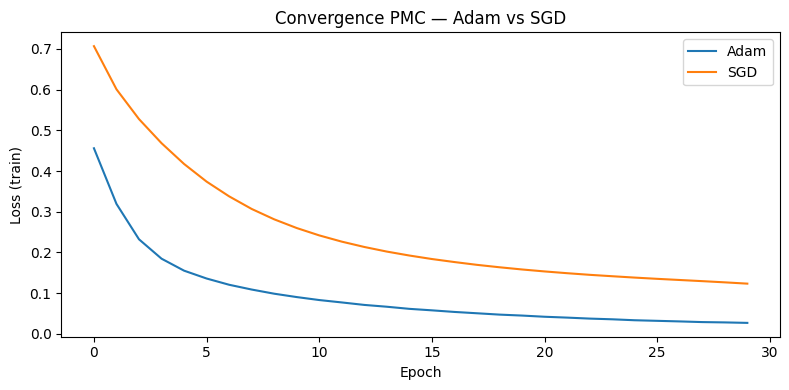

→ Adam converge généralement plus vite que SGD sur ce jeu.


In [ ]:

print("=== SGD vs Adam — courbes de loss ===")
histories = {}
for opt in ["adam", "sgd"]:
    model = build_pmc(optimizer=opt)
    h = model.fit(
        X_train_s, y_train, epochs=30, batch_size=16, verbose=0,
        validation_data=(scaler_boot.transform(X_val), y_val),
    )
    histories[opt] = h.history["loss"]

plt.figure(figsize=(8, 4))
plt.plot(histories["adam"], label="Adam")
plt.plot(histories["sgd"], label="SGD")
plt.xlabel("Epoch")
plt.ylabel("Loss (train)")
plt.title("Convergence PMC — Adam vs SGD")
plt.legend()
plt.tight_layout()
plt.show()
print("→ Adam converge généralement plus vite que SGD sur ce jeu.")

In [65]:
print("=== Verdict final sur le test (une seule fois) ===")
y_pred_final = champion.predict(X_test_s)
print(f"Accuracy test : {accuracy_score(y_test, y_pred_final):.2%}")
rapport_metier(y_test, y_pred_final, pos_label=0)
print("\nModèle sérialisé dans modele.joblib — API (api.py) + Streamlit (app.py) prêts.")

=== Verdict final sur le test (une seule fois) ===
Accuracy test : 95.61%
Matrice de confusion (lignes=vrai, cols=prédit) :
[[39  3]
 [ 2 70]]
precision=0.95  recall=0.93  F1=0.94  |  coût métier = 32

Modèle sérialisé dans modele.joblib — API (api.py) + Streamlit (app.py) prêts.
